<a href="https://colab.research.google.com/github/ketanp23/deeplearningclass/blob/main/DL_Lab5_Deep_Feedforward_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL Lab 5 · Deep Feedforward Networks (with PyTorch)

> **Deep Learning foundations — Lab.** Run top to bottom (Runtime → Run all). Read the notes, run the code, and finish
> the **Your turn 🧪** cell. We build from scratch with NumPy so nothing is hidden.

## What you'll build
Everything from Labs 1–4, but now with a real framework doing the calculus for you. You'll build a deep feedforward
net in **PyTorch**, train it on real images, and experiment with **architecture design** — how many hidden units and
layers to use.

> ⚡ Use a GPU: **Runtime → Change runtime type → T4 GPU**.

In [1]:
import torch, torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
dev = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| device:", dev)

PyTorch 2.11.0+cu128 | device: cuda


## 1 · The whole point of a framework: autograd
You describe the network; PyTorch computes back-prop automatically. Compare to Lab 4's hand-derived gradients.

In [2]:
w = torch.tensor([2.0], requires_grad=True)
loss = (w**2)              # f(w) = w^2
loss.backward()            # autograd fills w.grad
print("f'(2) computed by autograd:", w.grad.item(), " (matches 2w = 4)")

f'(2) computed by autograd: 4.0  (matches 2w = 4)


## 2 · Load MNIST (handwritten digits)

In [3]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,),(0.3081,))])
train_ds = datasets.MNIST(".", train=True,  download=True, transform=tf)
test_ds  = datasets.MNIST(".", train=False, download=True, transform=tf)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=256)
print("train:", len(train_ds), "test:", len(test_ds))

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.09MB/s]

train: 60000 test: 10000


## 3 · A deep feedforward network
Input 784 pixels → hidden layers with ReLU → 10-class softmax (via cross-entropy loss). This is **architecture
design**: the list of hidden sizes is yours to choose.

In [4]:
class MLP(nn.Module):
    def __init__(self, hidden=(256,128)):
        super().__init__()
        sizes = [784, *hidden, 10]
        layers = []
        for i in range(len(sizes)-1):
            layers.append(nn.Linear(sizes[i], sizes[i+1]))
            if i < len(sizes)-2: layers.append(nn.ReLU())   # ReLU between hidden layers
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

model = MLP(hidden=(256,128)).to(dev)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
trainable parameters: 235146


## 4 · Train (cross-entropy loss + gradient descent, done by the framework)

In [5]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
lossfn = nn.CrossEntropyLoss()

def evaluate():
    model.eval(); correct=0
    with torch.no_grad():
        for xb,yb in test_dl:
            pred = model(xb.to(dev)).argmax(1).cpu()
            correct += (pred==yb).sum().item()
    return correct/len(test_ds)

for epoch in range(3):
    model.train()
    for xb,yb in train_dl:
        opt.zero_grad()
        loss = lossfn(model(xb.to(dev)), yb.to(dev))
        loss.backward()          # autograd back-prop
        opt.step()               # gradient-descent update
    print(f"epoch {epoch+1}: test accuracy = {evaluate():.4f}")

epoch 1: test accuracy = 0.9597
epoch 2: test accuracy = 0.9715
epoch 3: test accuracy = 0.9745


## 5 · Architecture design — capacity vs. accuracy
Compare a tiny network to a bigger one. More hidden units usually helps — up to a point, after which you risk
overfitting and pay more compute.

In [6]:
import time
for hidden in [(16,), (256,128), (512,256,128)]:
    m = MLP(hidden).to(dev); opt = torch.optim.Adam(m.parameters(), 1e-3)
    t0=time.time()
    for _ in range(1):
        for xb,yb in train_dl:
            opt.zero_grad(); nn.CrossEntropyLoss()(m(xb.to(dev)), yb.to(dev)).backward(); opt.step()
    # quick eval
    m.eval(); c=0
    with torch.no_grad():
        for xb,yb in test_dl: c+=(m(xb.to(dev)).argmax(1).cpu()==yb).sum().item()
    n=sum(p.numel() for p in m.parameters())
    print(f"hidden={str(hidden):18} params={n:>8,}  acc(1 epoch)={c/len(test_ds):.3f}  time={time.time()-t0:.1f}s")

hidden=(16,)              params=  12,730  acc(1 epoch)=0.920  time=15.3s
hidden=(256, 128)         params= 235,146  acc(1 epoch)=0.961  time=15.3s
hidden=(512, 256, 128)    params= 567,434  acc(1 epoch)=0.960  time=14.7s


## Your turn 🧪
1. Swap `nn.ReLU` for `nn.Sigmoid` throughout — does the deep net train as well? (Watch for slow/vanishing gradients.)
2. Add `nn.Dropout(0.2)` between layers and train longer — does test accuracy improve (less overfitting)?
3. Rewrite the same model in **Keras** (`tf.keras.Sequential`) — notice how the framework choice barely changes the ideas.
4. Print a few test images with the model's predictions to see where it fails.

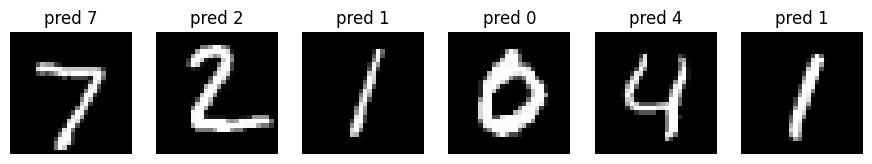

In [7]:
# Your turn: visualize predictions
import numpy as np
model.eval()
xb, yb = next(iter(test_dl))
with torch.no_grad(): pred = model(xb.to(dev)).argmax(1).cpu()
fig, ax = plt.subplots(1,6, figsize=(11,2))
for a,i in zip(ax, range(6)):
    a.imshow(xb[i,0], cmap="gray"); a.set_title(f"pred {pred[i].item()}"); a.axis("off")
plt.show()